# Distance-Weighted Interpolation - LOSO 5/10/15 -> 22

Inverse-distance weighting in 2D scalp space. Pure geometry baseline (no training, no scaler). Self-contained: copies its own channel sets, loaders, metrics, and run loop with `tqdm` progress.

Outputs:
- `../../Results/Distance_Weighted/distance_weighted_loso_metrics.csv`
- `../../Results/Distance_Weighted/distance_weighted_summary.json`
- `../../Results_Visualization/Distance_Weighted/*.png`

Note: this method is parameter-free; no checkpoint, scaler, or training plot are produced under `Model_Files/`.

## 1. Imports, paths, configuration

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from tqdm.auto import tqdm

METHOD_NAME = 'distance_weighted'
METHOD_TITLE = 'Distance_Weighted'
SFREQ = 250
MAX_TRAIN_SAMPLES = 0
MAX_TEST_SAMPLES = 0
MAX_SPLITS = 0

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != 'new_repository' and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if REPO_ROOT.name != 'new_repository':
    raise RuntimeError('Run from inside new_repository tree.')

PROCESSED_DIR = REPO_ROOT / 'Processed_BCI_Competition_Data'
RESULTS_DIR = REPO_ROOT / 'Results' / METHOD_TITLE
VIZ_DIR = REPO_ROOT / 'Results_Visualization' / METHOD_TITLE
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print('PROCESSED_DIR =', PROCESSED_DIR)
print('RESULTS_DIR   =', RESULTS_DIR)
print('VIZ_DIR       =', VIZ_DIR)


PROCESSED_DIR = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Processed_BCI_Competition_Data
RESULTS_DIR   = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Distance_Weighted
VIZ_DIR       = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Distance_Weighted


c:\Users\unnat\Desktop\EEGFeatureExtraction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Channel sets and data loaders (self-contained)

In [2]:
CHANNELS_22 = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4',
    'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz',
]
CHANNEL_SET_5 = ['Fz', 'C3', 'C4', 'Pz', 'POz']
CHANNEL_SET_10 = ['Fz', 'FC3', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CP4', 'Pz', 'POz']
CHANNEL_SET_15 = ['Fz', 'FC3', 'FC1', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CP2', 'CP4', 'Pz']
CHANNEL_SETS = [CHANNEL_SET_5, CHANNEL_SET_10, CHANNEL_SET_15]

CHANNEL_POS_2D = {
    'Fz': (0.00, 0.62), 'FC3': (-0.33, 0.34), 'FC1': (-0.14, 0.34), 'FCz': (0.00, 0.32),
    'FC2': (0.14, 0.34), 'FC4': (0.33, 0.34), 'C5': (-0.50, 0.00), 'C3': (-0.33, 0.00),
    'C1': (-0.14, 0.00), 'Cz': (0.00, 0.00), 'C2': (0.14, 0.00), 'C4': (0.33, 0.00),
    'C6': (0.50, 0.00), 'CP3': (-0.33, -0.30), 'CP1': (-0.14, -0.30), 'CPz': (0.00, -0.30),
    'CP2': (0.14, -0.30), 'CP4': (0.33, -0.30), 'P1': (-0.14, -0.52), 'Pz': (0.00, -0.54),
    'P2': (0.14, -0.52), 'POz': (0.00, -0.82),
}


def load_subject_data(subject_dir: Path):
    npz = np.load(subject_dir / 'trials.npz', allow_pickle=True)
    return npz['X'].astype(np.float32), npz['y'].astype(np.int32)


def to_sample_matrix(trials_ch_time):
    n_trials, n_channels, n_times = trials_ch_time.shape
    return np.transpose(trials_ch_time, (0, 2, 1)).reshape(n_trials * n_times, n_channels)


loso_splits = json.loads((PROCESSED_DIR / 'loso_splits.json').read_text(encoding='utf-8'))
if MAX_SPLITS > 0:
    loso_splits = loso_splits[:MAX_SPLITS]
print(f'Loaded {len(loso_splits)} LOSO splits.')


Loaded 9 LOSO splits.


## 3. Metrics: RMSE, MAE, R^2, Pearson r, band-wise PSD RMSE

In [3]:
def compute_metrics(y_true, y_pred):
    diff = y_true - y_pred
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae = float(np.mean(np.abs(diff)))
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    yt_c = yt - yt.mean()
    yp_c = yp - yp.mean()
    den = np.sqrt(np.sum(yt_c ** 2) * np.sum(yp_c ** 2))
    pearson_r = float(np.sum(yt_c * yp_c) / den) if den > 0 else float('nan')
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    return {'rmse': rmse, 'mae': mae, 'pearson_r': pearson_r, 'r2': r2}


def _band_power(psd, freqs, lo, hi):
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return np.zeros(psd.shape[0])
    return np.trapezoid(psd[:, mask], freqs[mask], axis=1)


def compute_band_metrics(y_true, y_pred, sfreq=SFREQ):
    nperseg = min(512, y_true.shape[0])
    freqs, psd_t = welch(y_true.T, fs=sfreq, nperseg=nperseg, axis=1)
    _, psd_p = welch(y_pred.T, fs=sfreq, nperseg=nperseg, axis=1)
    bands = {
        'delta': (0.5, 4.0), 'theta': (4.0, 8.0), 'alpha': (8.0, 13.0),
        'beta': (13.0, 30.0), 'gamma': (30.0, 45.0),
    }
    out = {}
    for name, (lo, hi) in bands.items():
        bt = _band_power(psd_t, freqs, lo, hi)
        bp = _band_power(psd_p, freqs, lo, hi)
        out[f'band_rmse_{name}'] = float(np.sqrt(np.mean((bt - bp) ** 2)))
    return out


## 4. Method-specific implementation: distance-weighted interpolation

In [4]:
def distance_weighted_interpolation(X_input, input_channels, target_channels):
    eps = 1e-8
    input_pos = np.array([CHANNEL_POS_2D[c] for c in input_channels], dtype=np.float32)
    preds = []
    for ch in target_channels:
        t_pos = np.array(CHANNEL_POS_2D[ch], dtype=np.float32)
        d = np.linalg.norm(input_pos - t_pos[None, :], axis=1)
        w = 1.0 / (d + eps)
        w = w / np.sum(w)
        preds.append((X_input * w[None, :]).sum(axis=1))
    return np.stack(preds, axis=1)


## 5. LOSO sweep with tqdm

In [6]:
rows = []
rng = np.random.default_rng(42)
viz_payloads = {}

outer = tqdm(loso_splits, desc='LOSO splits', unit='split')
for split in outer:
    test_subject = split['test_subject']
    outer.set_postfix(test=test_subject)
    x_test_trials, _ = load_subject_data(PROCESSED_DIR / test_subject)
    n_trials, _, n_times = x_test_trials.shape
    test_samples = to_sample_matrix(x_test_trials)
    if MAX_TEST_SAMPLES > 0 and test_samples.shape[0] > MAX_TEST_SAMPLES:
        test_samples = test_samples[rng.choice(test_samples.shape[0], size=MAX_TEST_SAMPLES, replace=False)]
    for ch_set in tqdm(CHANNEL_SETS, desc=f'{test_subject} channels', leave=False, unit='set'):
        input_idx = [CHANNELS_22.index(c) for c in ch_set]
        missing = [c for c in CHANNELS_22 if c not in ch_set]
        miss_idx = [CHANNELS_22.index(c) for c in missing]
        X_in = test_samples[:, input_idx]
        Y_true = test_samples[:, miss_idx]
        Y_pred = distance_weighted_interpolation(X_in, ch_set, missing)
        m = compute_metrics(Y_true, Y_pred)
        m.update(compute_band_metrics(Y_true, Y_pred))
        
        diff_per_ch = Y_true - Y_pred
        rmse_per_ch = np.sqrt(np.mean(diff_per_ch ** 2, axis=0))
        mae_per_ch = np.mean(np.abs(diff_per_ch), axis=0)
        
        r_per_ch = []
        r2_per_ch = []
        for ch_idx in range(len(missing)):
            yt = Y_true[:, ch_idx]
            yp = Y_pred[:, ch_idx]
            yt_c = yt - yt.mean()
            yp_c = yp - yp.mean()
            den = np.sqrt(np.sum(yt_c ** 2) * np.sum(yp_c ** 2))
            r = float(np.sum(yt_c * yp_c) / den) if den > 0 else float('nan')
            r_per_ch.append(r)
            
            ss_res = np.sum((yt - yp) ** 2)
            ss_tot = np.sum((yt - yt.mean()) ** 2)
            r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
            r2_per_ch.append(r2)
            
        base_row = {
            'test_subject': test_subject,
            'n_input_channels': len(ch_set),
            'input_channels': ','.join(ch_set),
            'n_reconstructed_channels': len(missing),
            'method': METHOD_NAME,
            **m,
            'n_test_trials': int(n_trials),
            'n_test_samples': int(test_samples.shape[0]),
        }
        
        # Append overall metrics
        rows.append({**base_row, **m})
        
        # Append per-channel metrics
        for ch_idx, ch_name in enumerate(missing):
            ch_row = base_row.copy()
            ch_row.update({
                'channel': ch_name,
                'rmse': float(rmse_per_ch[ch_idx]),
                'mae': float(mae_per_ch[ch_idx]),
                'pearson_r': float(r_per_ch[ch_idx]),
                'r2': float(r2_per_ch[ch_idx]),
            })
            rows.append(ch_row)
        x_full_trial = x_test_trials[0]
        samples_trial = to_sample_matrix(x_full_trial[None, :, :])
        x_in_trial = samples_trial[:, input_idx]
        y_true_trial = samples_trial[:, miss_idx]
        y_pred_trial = distance_weighted_interpolation(x_in_trial, ch_set, missing)
        viz_payloads[len(ch_set)] = {
            'test_subject': test_subject,
            'input_channels': list(ch_set),
            'missing_channels': list(missing),
            'y_true_trial': y_true_trial,
            'y_pred_trial': y_pred_trial,
            'n_times': int(x_full_trial.shape[1]),
            'Y_true_all': Y_true,
            'Y_pred_all': Y_pred,
        }

metrics_df = pd.DataFrame(rows)
metrics_df.head()


LOSO splits: 100%|██████████| 9/9 [00:28<00:00,  3.16s/split, test=A09T]


,test_subject,n_input_channels,input_channels,n_reconstructed_channels,method,rmse,mae,pearson_r,r2,band_rmse_delta,band_rmse_theta,band_rmse_alpha,band_rmse_beta,band_rmse_gamma,n_test_trials,n_test_samples,channel
0,A01T,5,"Fz,C3,C4,Pz,POz",17,distance_weighted,3.305309,2.570899,0.945703,0.892169,8.135236,4.096229,3.586561,2.778053,0.964242,273,273000,NaN
1,A01T,5,"Fz,C3,C4,Pz,POz",17,distance_weighted,3.648874,2.886981,0.930911,0.865928,8.135236,4.096229,3.586561,2.778053,0.964242,273,273000,FC3
2,A01T,5,"Fz,C3,C4,Pz,POz",17,distance_weighted,3.602013,2.852274,0.947225,0.887315,8.135236,4.096229,3.586561,2.778053,0.964242,273,273000,FC1
3,A01T,5,"Fz,C3,C4,Pz,POz",17,distance_weighted,4.097486,3.238759,0.940216,0.867219,8.135236,4.096229,3.586561,2.778053,0.964242,273,273000,FCz
4,A01T,5,"Fz,C3,C4,Pz,POz",17,distance_weighted,3.359297,2.665359,0.956828,0.903222,8.135236,4.096229,3.586561,2.778053,0.964242,273,273000,FC2


## 6. Save metrics CSV and summary JSON

In [7]:
csv_path = RESULTS_DIR / f'{METHOD_NAME}_loso_metrics_all.csv'
json_path = RESULTS_DIR / f'{METHOD_NAME}_summary_all.json'
metrics_df.to_csv(csv_path, index=False)

overall_df = metrics_df[metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else metrics_df
per_ch_df = metrics_df[~metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else pd.DataFrame()

metric_cols = ['rmse', 'mae', 'pearson_r', 'r2',
               'band_rmse_delta', 'band_rmse_theta', 'band_rmse_alpha',
               'band_rmse_beta', 'band_rmse_gamma']

summary_by_channels = (
    overall_df.groupby('n_input_channels', as_index=False)[metric_cols]
    .agg(['mean', 'std'])
)
summary_by_channels.columns = [
    c if isinstance(c, str) else (c[0] if c[1] == '' else f'{c[0]}_{c[1]}')
    for c in summary_by_channels.columns
]
summary_by_channels = summary_by_channels.reset_index(drop=True)

per_channel_summary = None
if not per_ch_df.empty:
    per_channel_summary = (
        per_ch_df.groupby(['n_input_channels', 'channel'], as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']]
        .agg(['mean', 'std'])
    )
    per_channel_summary.columns = [
        c if isinstance(c, str) else (c[0] if c[1] == '' else f'{c[0]}_{c[1]}')
        for c in per_channel_summary.columns
    ]
    per_channel_summary = per_channel_summary.reset_index(drop=True)

summary_dict = {
    'method': METHOD_NAME,
    'total_rows': int(len(metrics_df)),
    'overall_rows': int(len(overall_df)),
    'per_channel_rows': int(len(per_ch_df)),
    'mean_metrics_by_channel_count': summary_by_channels.to_dict(orient='records'),
}

if per_channel_summary is not None:
    summary_dict['per_channel_metrics_mean'] = per_channel_summary.to_dict(orient='records')

json_path.write_text(json.dumps(summary_dict, indent=2), encoding='utf-8')

print('✓ Saved metrics CSV    :', csv_path)
print('✓ Saved summary JSON   :', json_path)
if 'model_loaded' in metrics_df.columns:
    n_trained = (~overall_df['model_loaded']).sum()
    n_loaded = overall_df['model_loaded'].sum()
    print(f'  - New models trained: {n_trained}')
    print(f'  - Pretrained models used: {n_loaded}')



✓ Saved metrics CSV    : C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Distance_Weighted\distance_weighted_loso_metrics_all.csv
✓ Saved summary JSON   : C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Distance_Weighted\distance_weighted_summary_all.json


## 7. Visualization (RMSE/Pearson/R^2 vs channels, time-series overlay, topomap, PSD)

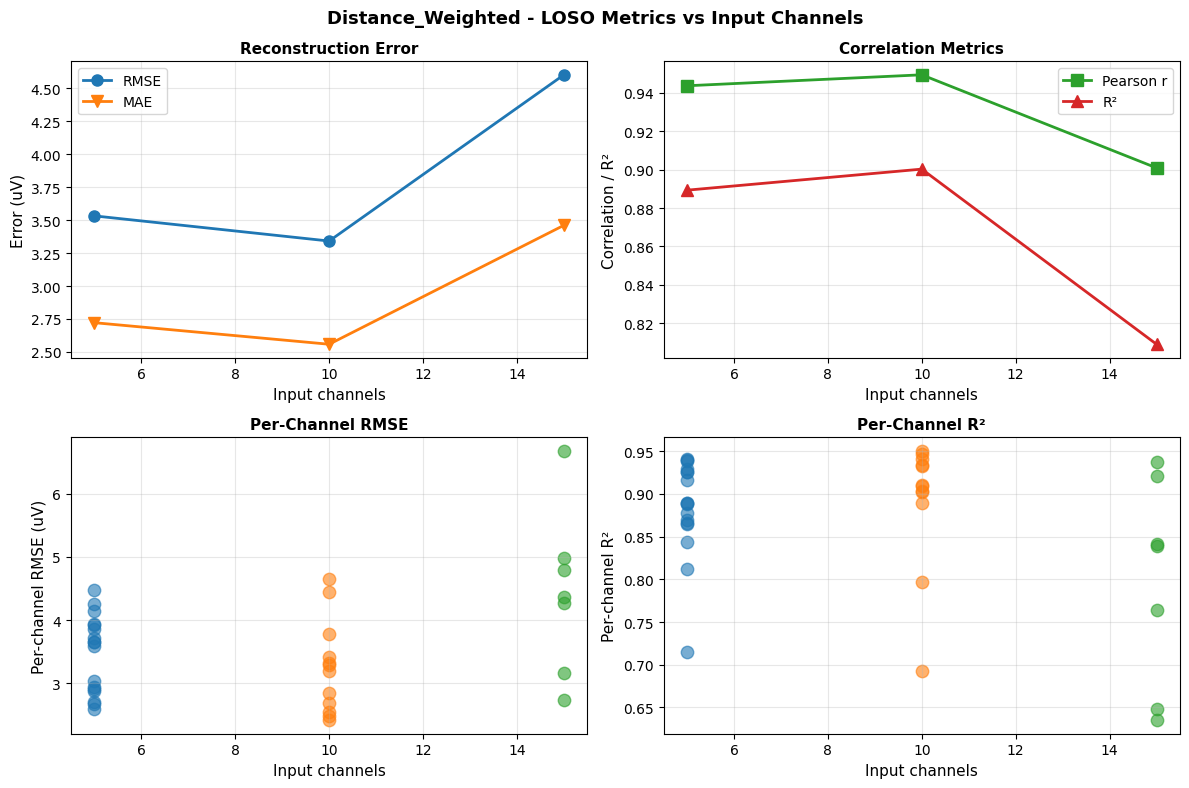

✓ Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Distance_Weighted\distance_weighted_metrics_vs_channels.png


In [8]:
# Plot metrics vs number of input channels (overall and per-channel)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Filter overall metrics (without 'channel' column)
overall_df_plot = metrics_df[metrics_df['channel'].isna()].copy() if 'channel' in metrics_df.columns else metrics_df
agg = overall_df_plot.groupby('n_input_channels', as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']].mean()

# Plot 1: Error metrics (RMSE, MAE)
ax = axes[0, 0]
ax.plot(agg['n_input_channels'], agg['rmse'], marker='o', linewidth=2, markersize=8, color='tab:blue', label='RMSE')
ax.plot(agg['n_input_channels'], agg['mae'], marker='v', linewidth=2, markersize=8, color='tab:orange', label='MAE')
ax.set_xlabel('Input channels', fontsize=11)
ax.set_ylabel('Error (uV)', fontsize=11)
ax.set_title('Reconstruction Error', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Correlation metrics (Pearson r, R²)
ax = axes[0, 1]
ax.plot(agg['n_input_channels'], agg['pearson_r'], marker='s', linewidth=2, markersize=8, color='tab:green', label='Pearson r')
ax.plot(agg['n_input_channels'], agg['r2'], marker='^', linewidth=2, markersize=8, color='tab:red', label='R²')
ax.set_xlabel('Input channels', fontsize=11)
ax.set_ylabel('Correlation / R²', fontsize=11)
ax.set_title('Correlation Metrics', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Per-channel RMSE distribution
if 'channel' in metrics_df.columns and not per_ch_df.empty:
    ax = axes[1, 0]
    for n_ch in [5, 10, 15]:
        ch_data = per_ch_df[per_ch_df['n_input_channels'] == n_ch]
        if not ch_data.empty:
            rmse_vals = ch_data.groupby('channel')['rmse'].mean()
            ax.scatter([n_ch]*len(rmse_vals), rmse_vals, s=80, alpha=0.6, label=f'{n_ch}ch')
    ax.set_xlabel('Input channels', fontsize=11)
    ax.set_ylabel('Per-channel RMSE (uV)', fontsize=11)
    ax.set_title('Per-Channel RMSE', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No per-channel data', ha='center', va='center')

# Plot 4: Per-channel R² distribution
if 'channel' in metrics_df.columns and not per_ch_df.empty:
    ax = axes[1, 1]
    for n_ch in [5, 10, 15]:
        ch_data = per_ch_df[per_ch_df['n_input_channels'] == n_ch]
        if not ch_data.empty:
            r2_vals = ch_data.groupby('channel')['r2'].mean()
            ax.scatter([n_ch]*len(r2_vals), r2_vals, s=80, alpha=0.6, label=f'{n_ch}ch')
    ax.set_xlabel('Input channels', fontsize=11)
    ax.set_ylabel('Per-channel R²', fontsize=11)
    ax.set_title('Per-Channel R²', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No per-channel data', ha='center', va='center')

fig.suptitle(f'{METHOD_TITLE} - LOSO Metrics vs Input Channels', fontsize=13, fontweight='bold')
fig.tight_layout()
out_p = VIZ_DIR / f'{METHOD_NAME}_metrics_vs_channels.png'
fig.savefig(out_p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {out_p}')



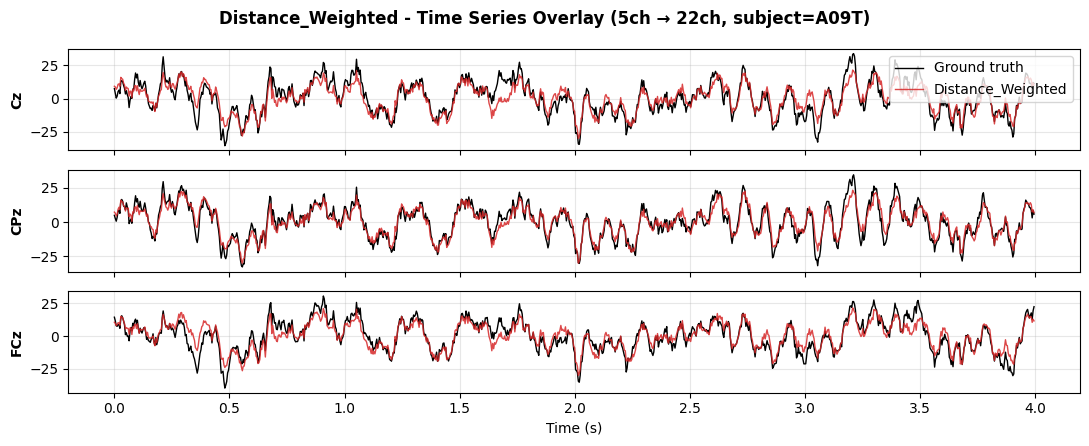

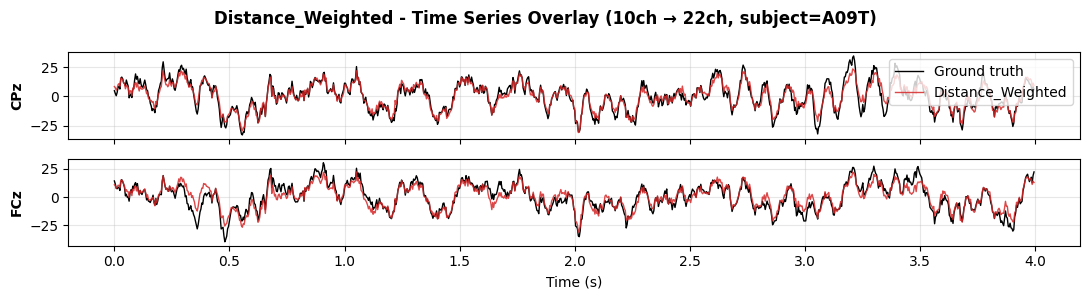

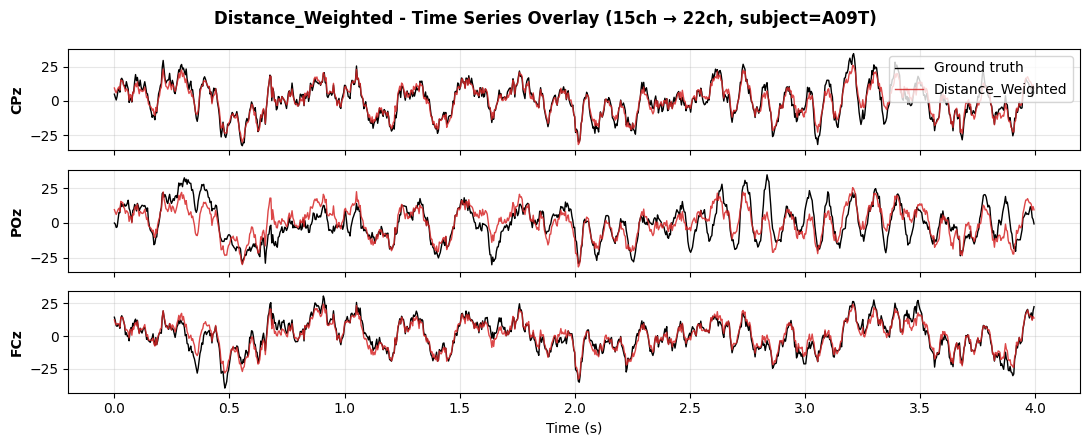

In [9]:
for n_in in [5, 10, 15]:
    if 'viz_payloads' not in locals() or n_in not in viz_payloads: continue
    
    viz_payload = viz_payloads[n_in]
    n_times, miss = viz_payload['n_times'], viz_payload['missing_channels']
    yt, yp = viz_payload['y_true_trial'], viz_payload['y_pred_trial']
    
    central_channels = ['Cz', 'C3', 'CPz', 'Pz', 'C4', 'POz', 'FCz', 'Fz']
    show_channels = [c for c in central_channels if c in miss][:6]
    if not show_channels: show_channels = miss[:6]
    
    times = np.arange(n_times) / SFREQ
    fig, axes = plt.subplots(len(show_channels), 1, figsize=(11, 1.5 * len(show_channels)), sharex=True)
    if len(show_channels) == 1: axes = [axes]
    
    for ax, ch in zip(axes, show_channels):
        idx = miss.index(ch)
        ax.plot(times, yt[:, idx], color='black', linewidth=1.0, label='Ground truth')
        ax.plot(times, yp[:, idx], color='tab:red', linewidth=1.0, alpha=0.85, label=METHOD_TITLE)
        ax.set_ylabel(ch, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    axes[0].legend(loc='upper right', fontsize=10)
    axes[-1].set_xlabel('Time (s)', fontsize=10)
    fig.suptitle(f'{METHOD_TITLE} - Time Series Overlay ({n_in}ch → 22ch, subject={viz_payload["test_subject"]})', fontsize=12, fontweight='bold')
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_timeseries_overlay.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()



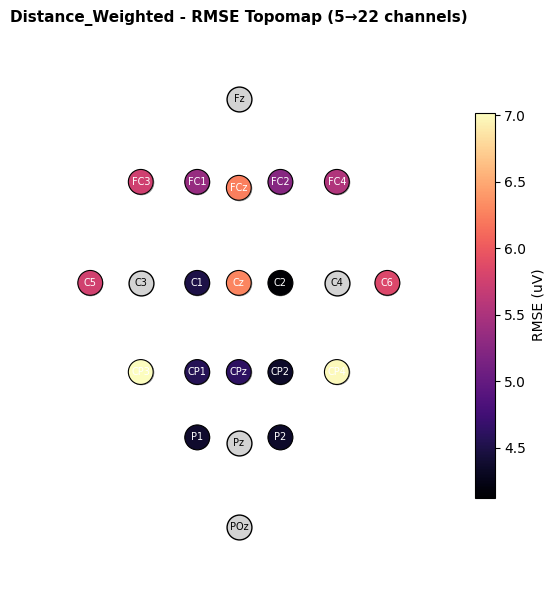

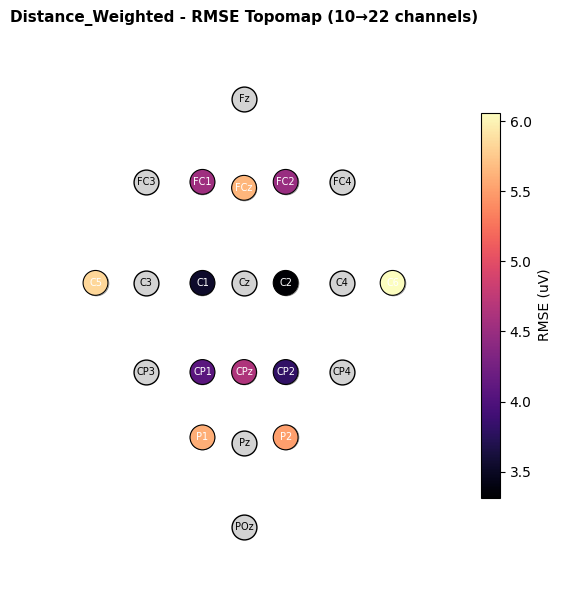

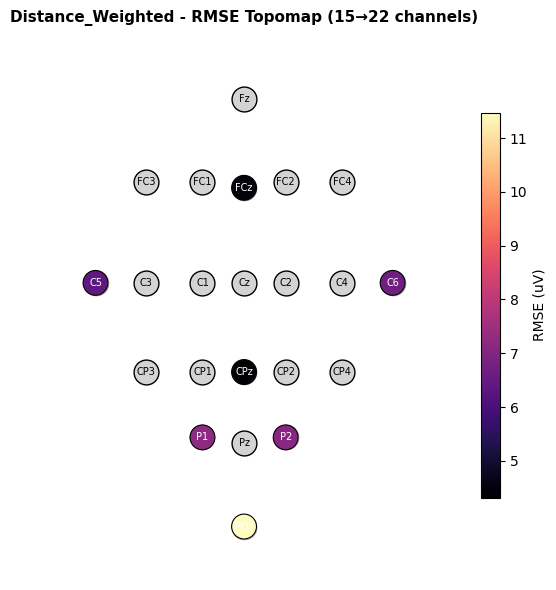

In [10]:
for n_in in sorted(viz_payloads.keys()) if 'viz_payloads' in locals() else []:
    viz_payload = viz_payloads[n_in]
    Y_true, Y_pred = viz_payload['Y_true_all'], viz_payload['Y_pred_all']
    miss, inp = viz_payload['missing_channels'], viz_payload['input_channels']
    
    rmse_per_ch = np.sqrt(np.mean((Y_true - Y_pred) ** 2, axis=0))
    fig, ax = plt.subplots(figsize=(6, 6))
    
    for ch in CHANNELS_22:
        x, y = CHANNEL_POS_2D[ch]
        if ch in inp:
            ax.scatter(x, y, c='lightgray', s=320, edgecolors='k', linewidths=1.0, zorder=2)
            ax.text(x, y, ch, ha='center', va='center', fontsize=7, zorder=3)
        else:
            ax.scatter(x, y, c='white', s=320, edgecolors='gray', linewidths=0.5, zorder=2)
    
    sc = ax.scatter([CHANNEL_POS_2D[c][0] for c in miss], [CHANNEL_POS_2D[c][1] for c in miss],
                    c=rmse_per_ch, cmap='magma', s=320, edgecolors='k', linewidths=0.8, zorder=4)
    
    for ch in miss:
        x, y = CHANNEL_POS_2D[ch]
        ax.text(x, y, ch, ha='center', va='center', fontsize=7, color='white', zorder=5)
    
    plt.colorbar(sc, ax=ax, shrink=0.7, label='RMSE (uV)')
    ax.set_xlim(-0.7, 0.7); ax.set_ylim(-1.0, 0.85); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'{METHOD_TITLE} - RMSE Topomap ({n_in}→22 channels)', fontsize=11, fontweight='bold')
    
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_rmse_topomap.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()



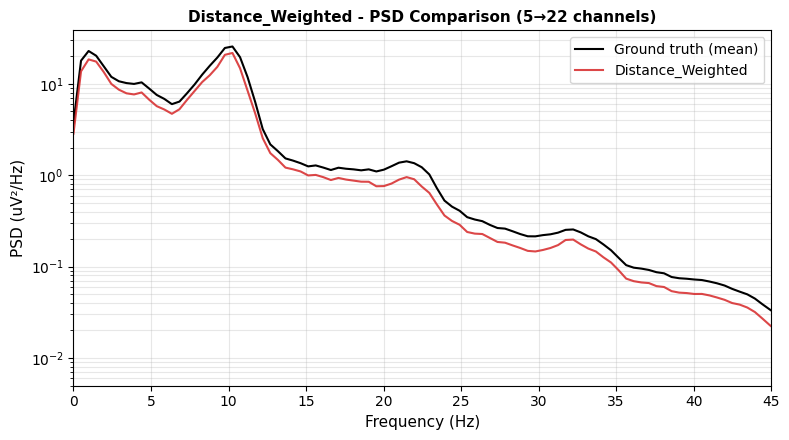

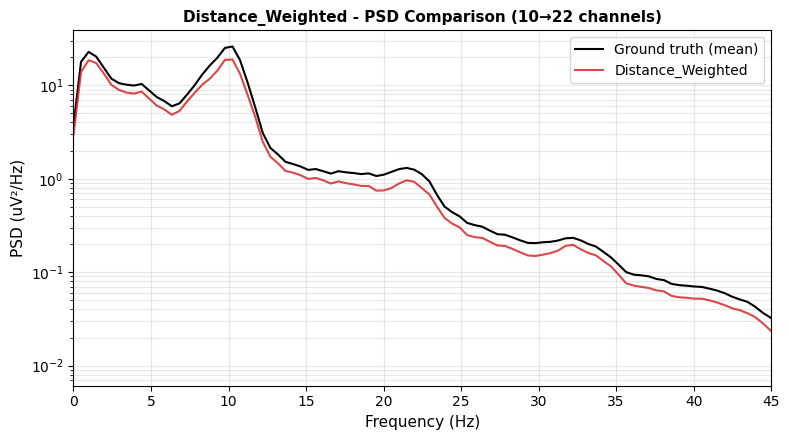

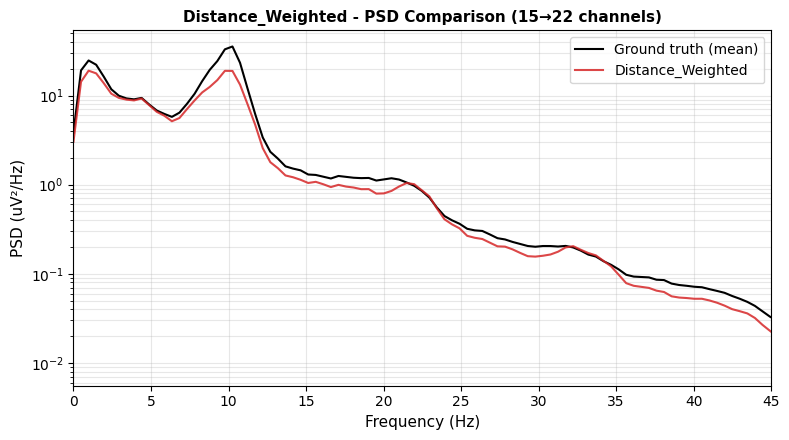

In [11]:
for n_in in sorted(viz_payloads.keys()) if 'viz_payloads' in locals() else []:
    viz_payload = viz_payloads[n_in]
    Y_true, Y_pred = viz_payload['Y_true_all'], viz_payload['Y_pred_all']
    
    nperseg = min(512, Y_true.shape[0])
    freqs, psd_t = welch(Y_true.T, fs=SFREQ, nperseg=nperseg, axis=1)
    _, psd_p = welch(Y_pred.T, fs=SFREQ, nperseg=nperseg, axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.semilogy(freqs, psd_t.mean(axis=0), color='black', linewidth=1.5, label='Ground truth (mean)')
    ax.semilogy(freqs, psd_p.mean(axis=0), color='tab:red', linewidth=1.5, alpha=0.85, label=METHOD_TITLE)
    ax.set_xlim(0, 45); ax.set_xlabel('Frequency (Hz)', fontsize=11); ax.set_ylabel('PSD (uV²/Hz)', fontsize=11)
    ax.set_title(f'{METHOD_TITLE} - PSD Comparison ({n_in}→22 channels)', fontsize=11, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    
    fig.tight_layout()
    out_p = VIZ_DIR / f'{METHOD_NAME}_{n_in}ch_psd_comparison.png'
    fig.savefig(out_p, dpi=150, bbox_inches='tight')
    plt.show()

